<a href="https://colab.research.google.com/github/hmmnyamminji/python/blob/main/%EC%8B%9C%EA%B3%84%EC%97%B4%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 환경 설정

In [1]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 pyplot 모듈
import matplotlib.font_manager as fm # 폰트 관리 모듈

# 드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/kwu/Bigdata/dataPreProcessing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font',family='NanumGothic') #matplotlib 기본 폰트로 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.sans-serif'] = ['NanumGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호가 깨지지 않도록 비활성화

print("현재 폰트: ", plt.rcParams['font.family'])

Mounted at /content/drive
현재 폰트:  ['NanumGothic']


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # 모든 경고 메세지를 무시하도록 설정

### datetime 객체 활용하기

In [11]:
from datetime import datetime

# 현재 날짜 시간 가져오기
t1 = datetime.now()
print('현재 시각:' , t1)

# 원하는 날따 시간으로 직접 생성
t2 = datetime(2020, 1, 2, 9, 0, 0) #datatime(년, 월, 시, 분, 초) 형식

# 두 datetime 객체의 차이 계산
diff = t1 - t2
print('₩경과 시간:' , diff)
print('경과 일수:' , diff.days) # 정수만 추출
print('자료형:' , type(diff))


현재 시각: 2026-03-19 07:51:43.361517
₩경과 시간: 2267 days, 22:51:43.361517
경과 일수: 2267
자료형: <class 'datetime.timedelta'>


### datetime으로 변환하기

In [16]:
# CSV 파일 경로
DATA_PATH = '/content/drive/MyDrive/kwu/Bigdata/visualization/samsung_stock.csv'

In [17]:
# 변환 전
df = pd.read_csv(DATA_PATH)
df.head()


,Date,Open,High,Low,Close,Volume
0,2020-01-02,54640,56325,54309,55000,13077813
1,2020-01-03,55625,56869,54386,55409,12694420
2,2020-01-06,55124,56452,54018,55294,20269936
3,2020-01-07,56363,57470,55053,55832,14850350
4,2020-01-08,57268,57737,56011,57107,21399173


In [18]:
# 변환 후
df['date_dt'] = pd.to_datetime(df['Date'])
df['date_fmt'] = pd.to_datetime(df['Date'], format = '%y-%m-%d')
df['date_yf'] = pd.to_datetime(df['Date'], yearfirst=True)

df.head()
df.info()

ValueError: time data "2020-01-02" doesn't match format "%y-%m-%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [20]:
# csv 로드 시 바로 datetime 변환
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df.head()


,Date,Open,High,Low,Close,Volume
0,2020-01-02,54640,56325,54309,55000,13077813
1,2020-01-03,55625,56869,54386,55409,12694420
2,2020-01-06,55124,56452,54018,55294,20269936
3,2020-01-07,56363,57470,55053,55832,14850350
4,2020-01-08,57268,57737,56011,57107,21399173


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1304 non-null   datetime64[ns]
 1   Open    1304 non-null   int64         
 2   High    1304 non-null   int64         
 3   Low     1304 non-null   int64         
 4   Close   1304 non-null   int64         
 5   Volume  1304 non-null   int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 61.3 KB


In [27]:
# 단일 Timestamp에서 속성 추출
pd.to_datetime('2026-03-19')
ts = pd.to_datetime('2026-03-19')

print('Timestamp: ', ts)
print('연도:', ts.year)
print('월:', ts.month)
print('일:', ts.day)
print('요일:', ts.weekday) # 0=월요일 6=일요일
print('분기:', ts.quarter)

Timestamp:  2026-03-19 00:00:00
연도: 2026
월: 3
일: 19
요일: <bound method Timestamp.weekday of Timestamp('2026-03-19 00:00:00')>
분기: 1


In [29]:
# df 접근자로 열 전체에 datetime 속성 적용, dt는 datetime64[ns] 타입의 Series에만 사용
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.weekday
df['quarter'] = df['Date'].dt.quarter
df['dayofyear'] = df['Date'].dt.dayofyear

print('추출된 열 자료형: ')
print(df[['year','month','day','weekday','quarter','dayofyear']].dtypes)


추출된 열 자료형: 
year         int32
month        int32
day          int32
weekday      int32
quarter      int32
dayofyear    int32
dtype: object


### Yahoo Finance에서 주식 데이터를 다운로드

In [30]:
%pip instiall yfinance -q
import yfinance as yf
df = yf.download('005930.KS', # 삼성전자 종목코드
                 start = '2020-01-01',
                 end='2026-03-18')
df.tail()

ERROR: unknown command "instiall" - maybe you meant "install"


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2026-03-11,190000.0,194800.0,187700.0,193000.0,24311356
2026-03-12,187900.0,190000.0,185900.0,186600.0,20440753
2026-03-13,183500.0,186200.0,179900.0,180000.0,19566331
2026-03-16,188700.0,189000.0,183600.0,184600.0,19747901
2026-03-17,193900.0,198000.0,193100.0,198000.0,20300082


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1519 entries, 2020-01-02 to 2026-03-17
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 005930.KS)   1519 non-null   float64
 1   (High, 005930.KS)    1519 non-null   float64
 2   (Low, 005930.KS)     1519 non-null   float64
 3   (Open, 005930.KS)    1519 non-null   float64
 4   (Volume, 005930.KS)  1519 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 71.2 KB


In [34]:
#멀티인덱스 컬럼 평단화 및 이름 변경
df_f = df[['Open','High','Low','Close','Volume']].copy()

if isinstance(df_f.columns, pd.MultiIndex):
  df_f.columns = df_f.columns.droplevel(1) #Multiindex의 두 번째 레벨을 제거

df_f.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1519 entries, 2020-01-02 to 2026-03-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1519 non-null   float64
 1   High    1519 non-null   float64
 2   Low     1519 non-null   float64
 3   Close   1519 non-null   float64
 4   Volume  1519 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 71.2 KB


In [35]:
df_f.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,47728.884596,48158.874547,47298.894644,47470.890625,12993228
2020-01-03,48158.892455,48674.880588,47212.914210,47728.902344,15422255
2020-01-06,47212.914210,47814.900366,46954.920144,47728.902344,10278951
2020-01-07,47900.888714,48502.874748,47814.890709,47986.886719,10009778
2020-01-08,48330.875289,49362.851274,48072.881293,48846.863281,23501171


In [37]:
#Datetimeindex 에서 시간 정보 추출
df_f['year'] = df_f.index.year
df_f['month'] = df_f.index.month
df_f['day'] = df_f.index.day
df_f['weekday'] = df_f.index.weekday
df_f['quarter'] = df_f.index.quarter
df_f['dayofyear'] = df_f.index.dayofyear

In [39]:
df_f.head()

Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear
Date,,,,,,,,,,,
2020-01-02,47728.884596,48158.874547,47298.894644,47470.890625,12993228,2020,1,2,3,1,2
2020-01-03,48158.892455,48674.880588,47212.914210,47728.902344,15422255,2020,1,3,4,1,3
2020-01-06,47212.914210,47814.900366,46954.920144,47728.902344,10278951,2020,1,6,0,1,6
2020-01-07,47900.888714,48502.874748,47814.890709,47986.886719,10009778,2020,1,7,1,1,7
2020-01-08,48330.875289,49362.851274,48072.881293,48846.863281,23501171,2020,1,8,2,1,8


In [41]:
# 요일별 평균 총가 분석
weekday_names = {0:'월', 1:'화', 2:'수', 3:'목', 4:'금', 5:'토', 6:'일'}

df_f['weekday_name'] = df_f['weekday'].map(weekday_names)


In [49]:
# 요일별 평균 종가 분석
weekly_close_avg = df_f.groupby('weekday_name')['Close'].mean().round(0)
print('요일별 평균 종가:\n', weekly_close_avg)

요일별 평균 종가:
 weekday_name
금    67626.0
목    67252.0
수    66966.0
월    67039.0
화    67613.0
Name: Close, dtype: float64


In [45]:
# 거래일(영업일) 번호 생성(0부터 순서대로)
df_f['trading_day'] = range(len(df_f))
elapsed_calendar_days = (df_f.index.max() - df_f.index.min()).days
print('경과 달력 일수:', elapsed_calendar_days)
print('거래일 순번:', df_f['trading_day'].iloc[-1])

경과 달력 일수: 2266
거래일 순번: 1518


### datetime 객체의 메서드 활용하기

In [53]:
# 연도별 평균 종가
yearly_colse = df_f.groupby(df_f.index.year)['Close'].mean().round(0)
print('연도별 평균 종가 \n', yearly_colse)


연도별 평균 종가 
 Date
2020     49724.0
2021     71685.0
2022     58998.0
2023     63856.0
2024     69072.0
2025     70635.0
2026    167463.0
Name: Close, dtype: float64


In [52]:
# 연도 x 분기별 평균 종가
quarterly_colse = df_f.groupby([df_f.index.year, df_f.index.quarter])['Close'].mean().round()
print('연도 분기별 평균 종가 \n', quarterly_colse)
print(type(quarterly_colse))

연도 분기별 평균 종가 
 Date  Date
2020  1        48076.0
      2        43745.0
      3        49339.0
      4        57782.0
2021  1        75473.0
      2        73918.0
      3        70537.0
      4        66973.0
2022  1        67249.0
      2        60018.0
      3        54246.0
      4        55105.0
2023  1        57566.0
      2        64084.0
      3        66124.0
      4        67781.0
2024  1        71536.0
      2        76147.0
      3        73863.0
      4        54780.0
2025  1        54644.0
      2        55932.0
      3        69998.0
      4       101998.0
2026  1       167463.0
Name: Close, dtype: float64
<class 'pandas.core.series.Series'>


In [60]:
# 멀티인덱스의 각 인덱스 이름 변경
quarterly_colse_renamed = quarterly_colse.rename_axis(index=['year','quarter'])
quarterly_colse_df = quarterly_colse_renamed.reset_index()

print(type(quarterly_colse_df))
quarterly_colse_df

<class 'pandas.core.frame.DataFrame'>


,year,quarter,Close
0,2020,1,48076.0
1,2020,2,43745.0
2,2020,3,49339.0
3,2020,4,57782.0
4,2021,1,75473.0
5,2021,2,73918.0
6,2021,3,70537.0
7,2021,4,66973.0
8,2022,1,67249.0
9,2022,2,60018.0


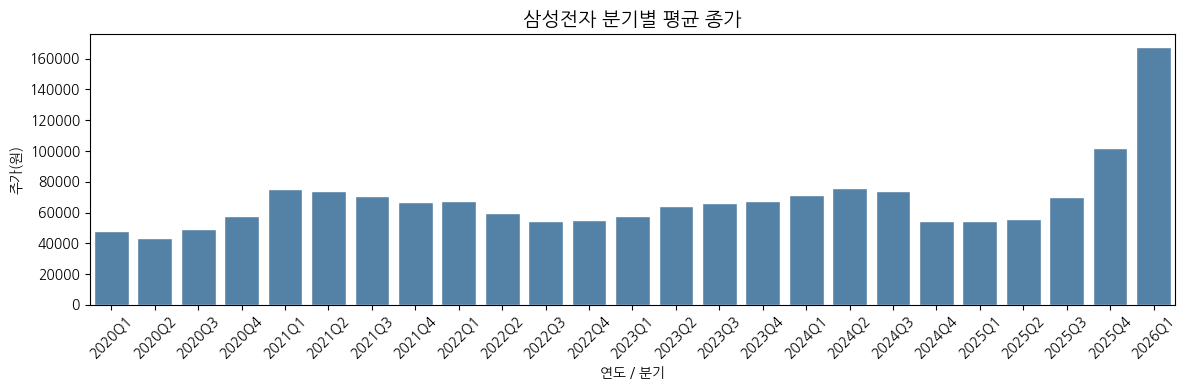

In [61]:
# 연도 - 분기별 평균 종가 시각화
fig, axes = plt.subplots(figsize=(12, 4))

quarterly_colse_df['year_quarter'] = quarterly_colse_df['year'].astype(str) + 'Q' + quarterly_colse_df['quarter'].astype(str)

sns.barplot(x='year_quarter', y='Close', data=quarterly_colse_df, ax=axes, color='steelblue', edgecolor='white')
axes.set_title('삼성전자 분기별 평균 종가', fontsize=14)
axes.set_xlabel('연도 / 분기')
axes.set_ylabel('주가(원)')
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [63]:
# Datetimeindex 상세 정보 확인
print('인덱스 정보:', df_f.index)
print('전체 기간:', df_f.index.min(), '~', df_f.index.max())
print('총 거래일 수:', len(df_f))

인덱스 정보: DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2026-03-04', '2026-03-05', '2026-03-06', '2026-03-09',
               '2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13',
               '2026-03-16', '2026-03-17'],
              dtype='datetime64[ns]', name='Date', length=1519, freq=None)
전체 기간: 2020-01-02 00:00:00 ~ 2026-03-17 00:00:00
총 거래일 수: 1519


In [64]:
# 연도 전체 추출
df_2025 = df_f.loc['2025']
print('2025년 데이터:', df_2025.shape)
df_2025.head()

2025년 데이터: (241, 13)


Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,trading_day
Date,,,,,,,,,,,,,
2025-01-02,51587.306948,52468.304600,51195.752436,52272.527344,16630538,2025,1,2,3,1,2,목,1229
2025-01-03,51685.199793,53936.638421,51685.199793,53251.417969,19318046,2025,1,3,4,1,3,금,1230
2025-01-06,53251.416592,55013.411994,53153.527959,54719.746094,19034284,2025,1,6,0,1,6,월,1231
2025-01-07,55600.741595,56090.184743,54230.300781,54230.300781,17030235,2025,1,7,1,1,7,화,1232
2025-01-08,53642.967905,56285.960849,53545.079277,56090.183594,26593553,2025,1,8,2,1,8,수,1233


In [65]:
# 특정 연-월 추출
df_2025_12 = df_f.loc['2025-12']
print('2025년 12월 데이터: ', df_2025_12.shape)
df_2025_12.head()

2025년 12월 데이터:  (21, 13)


Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,trading_day
Date,,,,,,,,,,,,,
2025-12-01,101506.562035,102302.691933,99416.721052,100312.367188,10905526,2025,12,1,0,4,335,월,1449
2025-12-02,100710.431848,102999.305300,100511.399374,102899.789062,13649487,2025,12,2,1,4,336,화,1450
2025-12-03,104193.501226,104989.631130,103496.887560,103994.468750,14697927,2025,12,3,2,4,337,수,1451
2025-12-04,103397.367686,104591.562500,102700.754044,104591.562500,11931145,2025,12,4,3,4,338,목,1452
2025-12-05,104790.598197,107875.601562,104093.984534,107875.601562,19755571,2025,12,5,4,4,339,금,1453


2022년 상반기 데이터:  (119, 13)


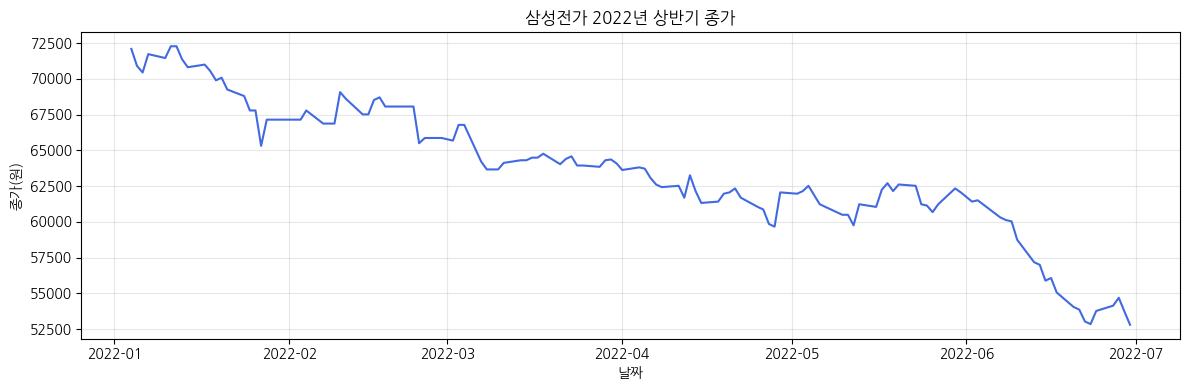

In [68]:
# 날짜 범위 슬라이싱 (loc[] 또는 직접 슬라이싱)
df_2022 = df_f['2022-01-01':'2022-06-30']
print('2022년 상반기 데이터: ', df_2022.shape)

fig, axes = plt.subplots(figsize=(12,4))
sns.lineplot(x=df_2022.index, y='Close', data=df_2022, ax=axes, color='royalblue', linewidth=1.5)
axes.set_title('삼성전가 2022년 상반기 종가')
axes.set_xlabel('날짜')
axes.set_ylabel('종가(원)')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
# dt 속성으로 조건 추출
mask = (df_f.index.year == 2026) & (df_f.index.month == 2)
df_2026_2 = df_f[mask]
print('dt 속성으로 추출한 2026년 2월: ', df_2026_2.shape)

dt 속성으로 추출한 2026년 2월:  (17, 13)


In [71]:
# Timedeltaindex 생성 및 추출
df_td = df_f.copy()
df_td['days_elapsed'] = df_td.index - df_td.index.min()

df_td = df_td.set_index('days_elapsed')
print('인덱스 자료형: ', type(df_td.index))
df_td.head()

인덱스 자료형:  <class 'pandas.core.indexes.timedeltas.TimedeltaIndex'>


Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,trading_day
days_elapsed,,,,,,,,,,,,,
0 days,47728.884596,48158.874547,47298.894644,47470.890625,12993228,2020,1,2,3,1,2,목,0
1 days,48158.892455,48674.880588,47212.914210,47728.902344,15422255,2020,1,3,4,1,3,금,1
4 days,47212.914210,47814.900366,46954.920144,47728.902344,10278951,2020,1,6,0,1,6,월,2
5 days,47900.888714,48502.874748,47814.890709,47986.886719,10009778,2020,1,7,1,1,7,화,3
6 days,48330.875289,49362.851274,48072.881293,48846.863281,23501171,2020,1,8,2,1,8,수,4


In [72]:
# Timedeltaindex로 기간 범위 추출
df_30day = df_td['0 days': '30 days']
print('첫 30일간 거래일 수: ', len(df_30day))
df_30day.head()

첫 30일간 거래일 수:  20


Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,trading_day
days_elapsed,,,,,,,,,,,,,
0 days,47728.884596,48158.874547,47298.894644,47470.890625,12993228,2020,1,2,3,1,2,목,0
1 days,48158.892455,48674.880588,47212.914210,47728.902344,15422255,2020,1,3,4,1,3,금,1
4 days,47212.914210,47814.900366,46954.920144,47728.902344,10278951,2020,1,6,0,1,6,월,2
5 days,47900.888714,48502.874748,47814.890709,47986.886719,10009778,2020,1,7,1,1,7,화,3
6 days,48330.875289,49362.851274,48072.881293,48846.863281,23501171,2020,1,8,2,1,8,수,4


### 시간 범위 다루기

In [88]:
# reindex()로 누락 날짜 채우기
df_2022_close = df_f.loc['2022', 'Close']
print('원본 거래일 수: ', len(df_2022_close))
display(df_2022_close)

full_range = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D') # 시간 주기를 일(Day) 단위로 설정

df_2022_full = df_2022_close.reindex(full_range)
display(df_2022_full)

print('reindex 후 전체 날짜 수:', len(df_2022_full))
print('NaN 개수 (주말+공휴일): ', df_2022_full.isna().sum())

weekend_check = df_2022_full[df_2022_full.isna()].index
print('누락 날짜 샘플(주말): ')
print(weekend_check[:5])


원본 거래일 수:  244


,Close
Date,
2022-01-04,72089.250000
2022-01-05,70898.445312
2022-01-06,70440.437500
2022-01-07,71722.843750
2022-01-10,71448.046875
...,...
2022-12-23,54191.640625
2022-12-26,54005.093750
2022-12-27,54191.640625


,Close
2022-01-01,NaN
2022-01-02,NaN
2022-01-03,NaN
2022-01-04,72089.250000
2022-01-05,70898.445312
...,...
2022-12-27,54191.640625
2022-12-28,53122.617188
2022-12-29,51902.484375
2022-12-30,NaN


reindex 후 전체 날짜 수: 365
NaN 개수 (주말+공휴일):  121
누락 날짜 샘플(주말): 
DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-08',
               '2022-01-09'],
              dtype='datetime64[ns]', freq=None)


In [90]:
# 열 방향으로 값 옮기기
# shift()를 활용한 시계열 이동 및 수익률 계산

df_s = df_f[['Close']].copy()

df_s['Close_led1'] = df_s['Close'].shift(1) # 데이터를 아래로 1칸 이동
df_s['Close_leg5'] = df_s['Close'].shift(5) # 데이터를 아래로 5칸 이동
df_s['Close_lead1'] = df_s['Close'].shift(-1) # 데이터를 위로 1칸 이동

print('shift 결과: \n', df_s.head(10))

shift 결과: 
 Price              Close    Close_led1    Close_leg5   Close_lead1
Date                                                              
2020-01-02  47470.890625           NaN           NaN  47728.902344
2020-01-03  47728.902344  47470.890625           NaN  47728.902344
2020-01-06  47728.902344  47728.902344           NaN  47986.886719
2020-01-07  47986.886719  47728.902344           NaN  48846.863281
2020-01-08  48846.863281  47986.886719           NaN  50394.839844
2020-01-09  50394.839844  48846.863281  47470.890625  51168.816406
2020-01-10  51168.816406  50394.839844  47728.902344  51598.796875
2020-01-13  51598.796875  51168.816406  47728.902344  51598.796875
2020-01-14  51598.796875  51598.796875  47986.886719  50738.828125
2020-01-15  50738.828125  51598.796875  48846.863281  52200.789062


In [92]:
# 월간 수익률 계산 (shift 활용의 가장 흔한 사례)
df_s['return_shift'] = df_s['Close'] / df_s['Close'].shift(1) # 오늘 종가 105 / 어제 종가 100 -1 -0.05 수익률 계산
df_s['return_pct'] = df_s['Close'].pct_change() # 수익률 자동 계산 함수

display(df_s[['Close','return_shift','return_pct']].head())
print('두 방법 차이 합계: ', (df_s['return_shift'] - (df_s['return_pct'] + 1)).sum())

Price,Close,return_shift,return_pct
Date,,,
2020-01-02,47470.890625,NaN,NaN
2020-01-03,47728.902344,1.005435,0.005435
2020-01-06,47728.902344,1.000000,0.000000
2020-01-07,47986.886719,1.005405,0.005405
2020-01-08,48846.863281,1.017921,0.017921


두 방법 차이 합계:  0.0


In [97]:
# 이동 평균 (Moving Average) - shift 응용
df_ma = df_f[['Close']].copy()

df_ma['MA5'] = df_ma['Close'].rolling(window=5).mean() # 현재 행을 기준으로 직전 5개의 데이터(윈도우)를 그룹화
df_ma['MA20'] = df_ma['Close'].rolling(window=20).mean()
df_ma['MA60'] = df_ma['Close'].rolling(window=60).mean() #60일간의 평균을 내면 전체적인 가격의 방향성(추세)을 더 쉽게 파악

#2022년 이동평균 시각화
fig, axes = plt.subplots(figsize=(14, 5))
df_ma.loc['2022', 'Close'].plot(ax=axes, color='lightgray'. linewidth=1, label='종가')
df_ma.loc['2022', 'MA5'].plot(ax=axes, color='royalblue'. linewidth=1.5, label='5일 이동평균')
df_ma.loc['2022', 'MA20'].plot(ax=axes, color='darkorange'. linewidth=1.5, label='20일 이동평균')
df_ma.loc['2022', 'MA60'].plot(ax=axes, color='crimson'. linewidth=2, label='60일 이동평균')

axes.set_title('삼성전자 2022년 이동평균선')
axes.set_xlabel('날짜')
axes.set_ylabel('종가(원)')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (1326593653.py, line 10)

###시간 주기 변경하기(리샘플링)

In [102]:
# resample() 은 Datetimelndex가 설정된 DataFrame에서만 사용 가능
# 다운샘플링: 일(Day) -> 월(Month)
monthly_close = df_f['Close'].resample('M')
print('월별 평균 종가: \n', monthly_close)
print('총 월 수:', len(monthly_close))

월별 평균 종가: 
 DatetimeIndexResampler [freq=<MonthEnd>, axis=0, closed=right, label=right, convention=start, origin=start_day]
총 월 수: 75


In [107]:
yearly_volume = df_f['Volume'].resample('A').sum() # 연도
print('연도별 총 거래량 : \n', yearly_volume)

연도별 총 거래량 : 
 Date
2020-12-31    5393337715
2021-12-31    4658484662
2022-12-31    3390581493
2023-12-31    2994215134
2024-12-31    5293964801
2025-12-31    4644967393
2026-12-31    1597121569
Freq: YE-DEC, Name: Volume, dtype: int64


In [108]:
# 업샘플링: 월(Month) -> 일(Day)
monthly_close = df_f['Close'].resample('MS').mean() # 월 시작일(MS) 기준
print('월별 데이터: \n', monthly_close)

daily_from_monthly = monthly_close.resample('B').asfreq() # 월별 데이터를 영업일(B) 기준 .asfreq() 데이터가 없는 날은 결측치(NaN)로 채움
print('일별 업샘플링 후 \n', daily_from_monthly)
print('NaN 개수: \n', daily_from_monthly.isna().sum())

월별 데이터: 
 Date
2020-01-01     50579.729492
2020-02-01     50811.922266
2020-03-01     43311.952237
2020-04-01     42489.133789
2020-05-01     42536.779400
                  ...      
2025-11-01    100212.851953
2025-12-01    108252.992932
2026-01-01    146542.857143
2026-02-01    180929.411765
2026-03-01    186590.909091
Freq: MS, Name: Close, Length: 75, dtype: float64
일별 업샘플링 후 
 Date
2020-01-01    50579.729492
2020-01-02             NaN
2020-01-03             NaN
2020-01-06             NaN
2020-01-07             NaN
                  ...     
2026-02-23             NaN
2026-02-24             NaN
2026-02-25             NaN
2026-02-26             NaN
2026-02-27             NaN
Freq: B, Name: Close, Length: 1608, dtype: float64
NaN 개수: 
 1555


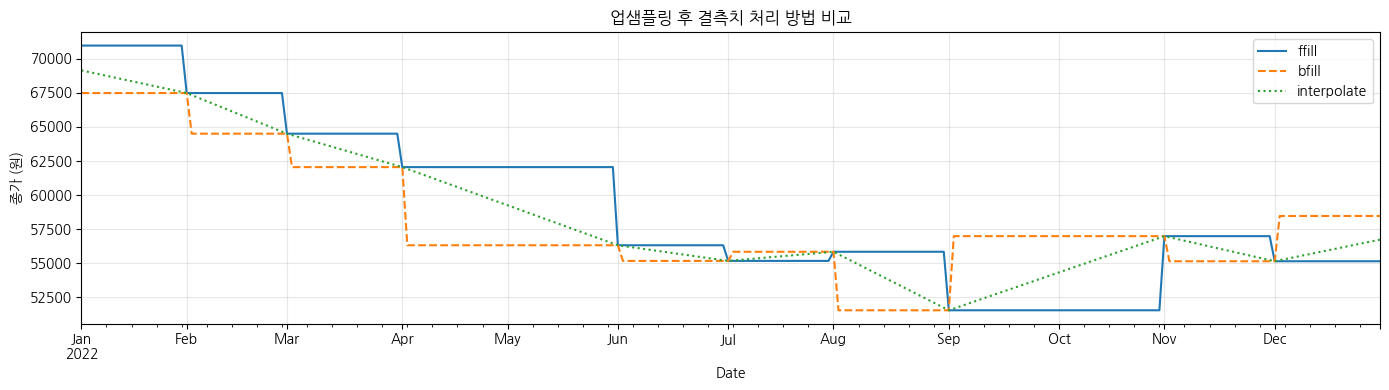

In [109]:
# 업샘플링 후 결측치 채우기 3가지 방법
daily_ffill = daily_from_monthly.ffill() # 누락된 값을 직전(forward) 유효한 값으로 채움
daily_bfill = daily_from_monthly.bfill() # 누락된 값을 직후(backward) 유효한 값으로 채움
daily_interp = daily_from_monthly.interpolate(method='linear') #누락된 값을 주변 유효한 값들을 기준으로 채움

# 결과 비교 시각화
fig, axes = plt.subplots(figsize=(14, 4))
daily_ffill['2022'].plot(ax=axes, label='ffill', linewidth=1.5)
daily_bfill['2022'].plot(ax=axes, label='bfill', linewidth=1.5, linestyle='--')
daily_interp['2022'].plot(ax=axes, label='interpolate', linewidth=1.5, linestyle=':')
axes.set_title('업샘플링 후 결측치 처리 방법 비교')
axes.set_ylabel('종가 (원)')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

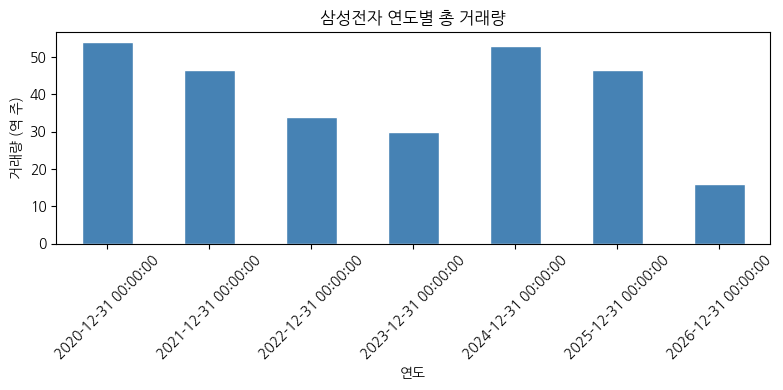

In [106]:
# 연도별 거래랑 트렌드 시각화
yearly_vol = df_f['Volume'].resample('A').sum() / 1e8   #0이 8개 붙음 -> 억 단위

fig, axes = plt.subplots(figsize=(8, 4))
yearly_vol.plot(kind='bar', ax=axes, color='steelblue', edgecolor='white')
axes.set_title('삼성전자 연도별 총 거래량')
axes.set_xlabel('연도')
axes.set_ylabel('거래량 (역 주)')
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 종합 실습 - 삼성전자 주식 시계열 대시보드

In [111]:
df_all - df_f.copy()

df_all['MA20'] = df_all['Close'].rolling(20).mean() # 20일 이동평균 (20일차 증가의 평균)
df_['MA60'] = df_all['Close'].rolling(60).mean()
df_all['Return']=df_all['Close'].pct_change() # 일간 수익률 계산 (전일 대비 증가 변화율)
df_all['year'] = df_all.index.year
df_all['month'] = df_all.index.month

# 대시보드 레이아웃
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('삼성전자 주식 시계열 분석 (2020~2026)')

ax = axes[0][0]
df_all['Close'].plot(ax=axes[0], color='lightgray', linewidth=0.8, label='증가')
df_all['MA20'].plot(ax=axes[0], color='royalblue', linewidth=1.5, label='MA20')
df_all['MA60'].plot(ax=axes[0], color='crimson', linewidth=2, label='MA60')
axes.set_title('증가 및 이동평균선')
axes.set_ylabel('주가 (원)')
axes.legend()
axes.grid(True, alpha=0.3)

axes = axes[0][1]
monthly_avg = df_all['Close'].resample('MS').mean()
monthly_avg.plot(ax=axes[1], color='darkorange', linewidth=2, marker='o', markersize=3)
axes.set_title('월별 평균 종가 (다운샘플링)')
axes.set_ylabel('주가 (원)')
axes.grid(True, alpha=0.3)

SyntaxError: invalid syntax (3430551362.py, line 17)